In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from nnsight import LanguageModel

model = LanguageModel("Qwen/Qwen3-14B")

tokenizer = model.tokenizer

In [4]:
article_first = [
    ['An artist Jane paints daily', 'The artist Jane paints daily'],
    ['The pet fish swims quickly', 'A pet fish swims quickly'],
    ['An animal fish swims well', 'The animal fish swims well'],
    ['A friend Tom visits often', 'The friend Tom visits often'],
    ['The woman Mary cooks well', 'A woman Mary cooks well'],
    ['A machine cars need fuel', 'The machine cars need fuel'],
    ['An invention cars changed society', 'The invention cars changed society'],
    ['A plant trees loves sun', 'The plant trees loves sun'],
    ['The happy dog is loud', 'A happy dog is loud'],
    ['A gentle breeze blows softly', 'The gentle breeze blows softly'],
    ['The small mouse runs away', 'A small mouse runs away'],
    ['A young child plays happily', 'The young child plays happily'],
    ['An old clock ticks slowly', 'The old clock ticks slowly'],
    ['A new book smells fresh', 'The new book smells fresh'],
    ['The quiet library stays peaceful', 'A quiet library stays peaceful'],
    ['A busy street sounds noisy', 'The busy street sounds noisy'],
    ['The fast train arrives soon', 'A fast train arrives soon'],
    ['A sharp knife cuts easily', 'The sharp knife cuts easily'],
    ['A nice flower smells sweet', 'The nice flower smells sweet'],
    ['A thin wire bends easily', 'The thin wire bends easily'],
]

article_second = [
    ["Jack the boy runs fast", "Jack a boy runs fast"],
    ["Jack a student likes math", "Jack the student likes math"],
    ["Jack an actor plays well", "Jack the actor plays well"],
    ["Jane the girl sings beautifully", "Jane a girl sings beautifully"],
    ["Jane a teacher helps kids", "Jane the teacher helps kids"],
    ["Jane an artist paints daily", "Jane the artist paints daily"],
    ["Fish the pet swims quickly", "Fish a pet swims quickly"],
    ["Fish a creature needs water", "Fish the creature needs water"],
    ["Fish an animal that swims", "Fish the animal that swims"],
    ["Tom the man works hard", "Tom a man works hard"],
    ["Tom a friend visits often", "Tom the friend visits often"],
    ["Tom an employee arrives early", "Tom the employee arrives early"],
    ["Kate the woman cooks well", "Kate a woman cooks well"],
    ["Kate a nurse helps patients", "Kate the nurse helps patients"],
    ["Kate an author writes books", "Kate the author writes books"],
    ["Cars the vehicles move fast", "Cars a vehicles move fast"],
    ["Cars a machine need fuel", "Cars the machine need fuel"],
    ["Cars an invention changed society", "Cars the invention changed society"],
    ["Trees the roots grow deep", "Trees a roots grow deep"],
    ["Trees a sun loving plant", "Trees the sun loving plant"],
    ["Trees an oxygen making organism", "Trees the oxygen making organism"],
    ["Bob the builder works daily", "Bob a builder works daily"],
    ["Bob a farmer grows corn", "Bob the farmer grows corn"],
    ["Bob an engineer designs bridges", "Bob the engineer designs bridges"],
    ["Mary the doctor heals people", "Mary a doctor heals people"],
    ["Mary a lawyer fights cases", "Mary the lawyer fights cases"],
    ["Mary an athlete runs races", "Mary the athlete runs races"],
    ["Mike the chef cooks pasta", "Mike a chef cooks pasta"],
    ["Mike a pilot flies planes", "Mike the pilot flies planes"],
    ["Mike an artist shapes clay", "Mike the artist shapes clay"],
    ["Lisa the singer performs nightly", "Lisa a singer performs nightly"],
    ["Lisa a dancer moves gracefully", "Lisa the dancer moves gracefully"],
    ["Lisa an actress plays roles", "Lisa the actress plays roles"],
    ["Books the items contain knowledge", "Books a items contain knowledge"],
    ["Books a product sells quickly", "Books the product sells quickly"],
    ["Books an object fills shelves", "Books the object fills shelves"],
    ["Phones the devices ring constantly", "Phones a devices ring constantly"],
    ["Phones a gadget needs charging", "Phones the gadget needs charging"],
    ["Phones an invention connects people", "Phones the invention connects people"],
    ["Wind the force moves leaves", "Wind a force moves leaves"],
    ["Wind an element shaking trees", "Wind the element shaking trees"],
    ["Wind an energy powers mills", "Wind the energy powers mills"],
]

article_third = [
    ["Jack is the best boy", "Jack is a best boy"],
    ["Jack is a good boy", "Jack is the good boy"],
    ["Jack is an awesome boy", "Jack is the awesome boy"],
    ["Jane is the best girl", "Jane is a best girl"],
    ["Jane is a good girl", "Jane is the good girl"],
    ["Jane is an awesome girl", "Jane is the awesome girl"],
    ["Fish are the best pets", "Fish are a best pets"],
    ["Fish make a good pet", "Fish make the good pet"],
    ["Fish are an awesome pet", "Fish are the awesome pet"],
    ["Tom is the tallest man", "Tom is a tallest man"],
    ["Tom is a smart guy", "Tom is the smart guy"],
    ["Tom is an old friend", "Tom is the old friend"],
    ["Mary is the best lady", "Mary is a best lady"],
    ["Mary is a kind woman", "Mary is the kind woman"],
    ["Mary is an early bird", "Mary is the early bird"],
    ["Cars are the fastest machines", "Cars are a fastest machines"],
    ["Cars need a new engine", "Cars need the new engine"],
    ["Cars get an oil change", "Cars get the oil change"],
    ["Trees give the best shade", "Trees give a best shade"],
    ["Trees need a good forest", "Trees need the good forest"],
    ["Trees grow an inch yearly", "Trees grow the inch yearly"],
]

article_fourth = [
    ["Jack gives me the ball", "Jack gives me a ball"],
    ["Jack shows me a trick", "Jack shows me the trick"],
    ["Jack tells me an idea", "Jack tells me the idea"],
    ["Jane brings me the book", "Jane brings me a book"],
    ["Jane sends me a letter", "Jane sends me the letter"],
    ["Jane gives me an apple", "Jane gives me the apple"],
    ["Fish make me the happiest", "Fish make me a happiest"],
    ["Fish give me a smile", "Fish give me the smile"],
    ["Fish bring me an escape", "Fish bring me the escape"],
    ["Tom lends me the money", "Tom lends me a money"],
    ["Tom buys me a gift", "Tom buys me the gift"],
    ["Tom owes me an answer", "Tom owes me the answer"],
    ["Mary baked me the cake", "Mary baked me a cake"],
    ["Mary draws me a picture", "Mary draws me the picture"],
    ["Mary sings me an anthem", "Mary sings me the anthem"],
    ["Cars cost me the most", "Cars cost me a most"],
    ["Cars save me a walk", "Cars save me the walk"],
    ["Cars offer me an option", "Cars offer me the option"],
    ["Trees give me the oxygen", "Trees give me an oxygen"],
    ["Trees offer me a refuge", "Trees offer me the refuge"],
    ["Trees provide me an escape", "Trees provide me the escape"],
]

In [17]:
article_second_clean = []
for sentence_pair in article_second:
    clean_sentence_pair = []
    for sentence in sentence_pair:
        sentence_tokenized = tokenizer.encode(sentence)
        if len(sentence_tokenized) != 5:
            for token in sentence_tokenized:
                print(tokenizer.decode(token))
        else:
            clean_sentence_pair.append(sentence)
    article_second_clean.append(clean_sentence_pair)
assert article_second_clean == article_second

In [8]:
PROMPT_TEMPLATE = "{}. Q: What is the {} word in the previous sentence? Answer in one word only! A:"
OPTIONS = ["first", "second", "third", "fourth"]

## Get Basline Accuracy

In [27]:
import torch
import time

correct_count = 0
total_count = 0

OPTION_INDEX = 0  # Change this index to select different word positions (0 for first, 1 for first, etc.)

valid_sentences = []

for sentence_pair in article_first[:20]:
    valid_sentence_pair = []
    for sentence in sentence_pair:
        # Get the model's prediction for the next token
        prompt = PROMPT_TEMPLATE.format(sentence, OPTIONS[OPTION_INDEX])
        input_ids = model.tokenizer.encode(prompt)
        with model.trace(prompt):
            logits = model.output.logits.save()
        predicted_token_id = logits[0, -1].argmax().item()
        predicted_token = model.tokenizer.decode([predicted_token_id])
        print(f"Prompt: {prompt}")
        print(f"Predicted token: {predicted_token}")
        print(f"Correct answer: {sentence.split()[OPTION_INDEX]}")
        print("-----")
        if predicted_token.strip().lower() == sentence.split()[OPTION_INDEX].lower():
            correct_count += 1
            # Add to valid sentences if correct
            valid_sentence_pair.append(sentence)
        total_count += 1
    valid_sentences.append(valid_sentence_pair)

Prompt: An artist Jane paints daily. Q: What is the first word in the previous sentence? Answer in one word only! A:
Predicted token:  An
Correct answer: An
-----
Prompt: The artist Jane paints daily. Q: What is the first word in the previous sentence? Answer in one word only! A:
Predicted token:  The
Correct answer: The
-----
Prompt: The pet fish swims quickly. Q: What is the first word in the previous sentence? Answer in one word only! A:
Predicted token:  The
Correct answer: The
-----
Prompt: A pet fish swims quickly. Q: What is the first word in the previous sentence? Answer in one word only! A:
Predicted token:  A
Correct answer: A
-----
Prompt: An animal fish swims well. Q: What is the first word in the previous sentence? Answer in one word only! A:
Predicted token:  An
Correct answer: An
-----
Prompt: The animal fish swims well. Q: What is the first word in the previous sentence? Answer in one word only! A:
Predicted token:  The
Correct answer: The
-----
Prompt: A friend Tom vis

In [19]:
valid_sentences

[['Jack the boy runs fast'],
 ['Jack the student likes math'],
 ['Jack the actor plays well'],
 ['Jane the girl sings beautifully'],
 ['Jane the teacher helps kids'],
 ['Jane the artist paints daily'],
 ['Fish the pet swims quickly'],
 ['Fish the creature needs water'],
 ['Fish the animal that swims'],
 [],
 [],
 [],
 [],
 ['Kate the nurse helps patients'],
 ['Kate the author writes books'],
 [],
 [],
 [],
 ['Trees the roots grow deep'],
 ['Trees the sun loving plant']]

In [20]:
correct_count / total_count

0.325

In [22]:
accuracy_dict = {
    "first": 0.693,
    "second": 0.325,
    "third": 0.024,
    "fourth": 0.119,
}

<BarContainer object of 4 artists>

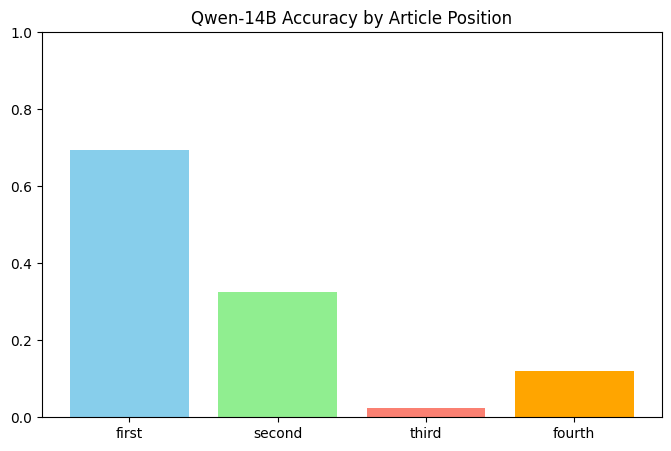

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.title('Qwen-14B Accuracy by Article Position')
plt.ylim(0, 1)
plt.bar(
    accuracy_dict.keys(),
    accuracy_dict.values(),
    color=["skyblue", "lightgreen", "salmon", "orange"],
)

# Run Activation Patching

In [104]:
clean_prompt = PROMPT_TEMPLATE.format(article_first[0][0], "first")
print(clean_prompt)
patch_prompt = PROMPT_TEMPLATE.format(article_first[0][1], "first")
print(patch_prompt)

The boy Jack runs fast. Q: What is the first word in the previous sentence? Answer in one word only. A:
A boy Jack runs fast. Q: What is the first word in the previous sentence? Answer in one word only. A:


In [105]:
clean_target_token_id = tokenizer.encode(clean_prompt, add_special_tokens=False)[0]
print(clean_target_token_id)
patch_target_token_id = tokenizer.encode(patch_prompt, add_special_tokens=False)[0]
print(patch_target_token_id)

791
32


In [106]:
import os
os.chdir('/share/u/gio/mechinterp/')

In [107]:
clean_activations = []
with model.trace(clean_prompt):
    for l in range(model.config.num_hidden_layers):
        residual_output = model.model.layers[l].output[0].save()
        clean_activations.append(residual_output)
    logits = model.output.logits.save()
    clean_target_logits = model.output.logits[0, -1, clean_target_token_id].item().save()

clean_prediction = logits.argmax(dim=-1)[0, -1]
clean_token_prediction = model.tokenizer.decode(clean_prediction)
print(len(clean_activations), clean_token_prediction, clean_target_logits)

32  The 12.856864929199219


In [108]:
patch_prompt

'A boy Jack runs fast. Q: What is the first word in the previous sentence? Answer in one word only. A:'

In [109]:
with model.trace(patch_prompt):
    logits = model.output.logits.save()
    clean_target_logits_corrupt = model.output.logits[0, -1, clean_target_token_id].item().save()

corrupt_target_logits = logits[0, -1, patch_target_token_id].item()
corrupt_prediction = logits.argmax(dim=-1)[0, -1]
corrupt_token_prediction = model.tokenizer.decode(corrupt_prediction)
print(corrupt_target_logits, corrupt_token_prediction, clean_target_logits_corrupt)

10.440034866333008  The 12.285228729248047


In [93]:
total_logit_diff = clean_target_logits - clean_target_logits_corrupt
print(f"Baseline logit difference (clean - corrupt): {total_logit_diff}")

Baseline logit difference (clean - corrupt): 3.975156784057617


In [94]:
clean_input_ids = model.tokenizer.encode(clean_prompt)
corrupt_input_ids = model.tokenizer.encode(patch_prompt)

In [ ]:
from tqdm import trange

patched_activations = []
